# Observations preparation
@Author: Nyota Buduli Masirika

In [2]:
#packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from astropy.io import fits
from astropy import units as u
import os 
import scopesim as sim
from astropy.wcs import WCS

In [3]:
#Changement of folder (needed to work with ScopeSim)
os.chdir("ScopeSim") #relative path to ScopeSim folder
print(os.getcwd())


c:\Users\Nyota\OneDrive - Universite de Liege\MASTER 3\TFE_AGN\Code\ScopeSim


## Functions and Variables
Codes to compile before continuing as the variables and functions are used in different parts of the notebook.

### i. Files
To create the `FITS` file, we must make the header compatible with `ScopeSim`. Let's load the header of an example image used for `ScopeSim` to see the good header format. If you do not have the example file, uncomment the box below to download the file and set the associate variables.

In [5]:
# Example FITS file
"""
example_FITS = sim.download_example_data("HL_Tau_prep_for_Scopesim.fits") #To download the file
"""
example_FITS = '../data/HL_Tau_prep_for_Scopesim.fits'

file_real_circinus_N_band = '../outputs/models/REAL_Circinus_N_band.fits'
file_real_circinus_N_band_untouched = '../data/N_band_Circinus_untouched.fits'

### ii. Useful Variables

General variables linked to METIS, ScopeSim, etc.

In [6]:
# Constants
L_band = 4 *u.um 
N_band = 12 *u.um 

# Variables linked to METIS
d_METIS = 39.3 * u.m # diameter of the primary mirror in the ELT

# Variables linked to ScopeSim
screen_size = 2048 # the size of the screen returned
screen_center = 1024 # the center of the source is located at the center of the screen
N_band_pixel_scale = 6.79 *u.mas # given by the header of the image generated by ScopeSim
L_band_pixel_scale = 6.79 *u.mas #! To change, not the good value

exptime_1hour = 3600 *u.s
exptime_1second = 1 *u.s

### iii. Mean Variance
Function to apply the error propagation formula to retrieve the mean Variance of an array:

$$\sigma_\text{mean}^2 = \frac{1}{N} \sigma_\text{tot}^2 = \frac{1}{N} \sum^N_i \sigma_i^2$$

where $N$ is the number of pixel in the subarray and the variance for a Poisson distribution is
$$\sigma^2 = \lambda * t$$
with $\lambda$ the rate at which the photons arrive and $t$ the integration time.

In [7]:
def mean_Variance(rate, t):
    N = np.size(rate)
    return np.sum(rate)*t/N

### iv. Pc to mas converter and mas to pc converter
Function to convert the size in pc to the angular size in mas, using the distance to the source using:
$$\theta = 2 \arctan\left(\frac{S}{2D}\right)$$
with 
- $S$: the size in parsecs,
- $D$: the distance to the object in parsecs,
- $\theta$: the angular size in radians.

In [8]:
def pc_to_mas(D, S):
    """Convert the size of an object in pc to its angular size in mas using the distance to the source

    Args:
        D (Quantity): Distance between the source and the detector [length]
        S (Quantity): Size of the object [length]

    Returns:
        Quantity: Angular size of the object in mas
    """
    D = D.to(u.pc)
    S = S.to(u.pc)
    mas = 2*np.arctan(S/2/D)
    mas = mas.to(u.mas)
    return mas

Function to convert the angular size in mas to the size in pc, using the distance to the source, as before.

In [9]:
def mas_to_pc(theta, D):
    """Convert the angular size of an object in mas to its size in pc using the distance to the source

    Args:
        theta (Quantity): Angular size [angle]
        D (Quantity): Distance between the source and the detector [length]

    Returns:
        Quantity: Size of the object in pc
    """
    D = D.to(u.pc)
    theta = theta.to(u.radian)
    pc = 2*D*np.tan(theta/2)
    pc = pc.to(u.pc)
    return pc

## 1. Angular resolution of METIS 

To determine the angular resolution, we apply the Rayleigh criterion. It is expressed as follows:

$$\theta = 1.22 \frac{\lambda}{D}$$
with 
* $\theta$ the angular resolution,
* $\lambda$ the wavelength,
* $D$ the diameter.

In [8]:
def Rayleigh_criterion(wavelength, diameter):
    """Apply the Rayleigh criterion to the telescope at the right wavelength

    Args:
        wavelength (Quantity): wavelength in meter
        diameter (Quantity): diameter of the mirror in meter

    Returns:
        Quantity: angular resolution of the telescope in mas
    """
    wavelength= wavelength.to(u.m)
    diameter = diameter.to(u.m)
    
    theta = 1.22*wavelength/diameter *u.rad
    theta = theta.to(u.mas)
    return theta

# Application of the Rayleigh criterion to ELT in the L-band and N-band
angular_resolution_L_band = Rayleigh_criterion(L_band, d_METIS) #[mas]
angular_resolution_N_band = Rayleigh_criterion(N_band, d_METIS) #[mas]
print(f"Angular resolutiuon in N-band =  {angular_resolution_N_band:.3f}")
print(f"Angular resolutiuon in L-band =  {angular_resolution_L_band:.3f}")

Angular resolutiuon in N-band =  76.838 mas
Angular resolutiuon in L-band =  25.613 mas


## 2. Angular size of 253 galaxies

To select the best candidates to make our observationswith METIS, we need to discriminate them with different criteria. The main one is the angular resolution of the AGN. To determine them, we use the database from the paper [*"The subarcsecond mid-infrared view of local active galactic nuclei: I. The N- and Q-band imaging atlas"* by D. Asmus et al.](https://arxiv.org/abs/1310.2770). The angular size of the galaxies are not directly communicated so we have to apply a bit of trigonometry. As we have the size of the source (in pc) and its distance, we can easily derive the angular size. 

Firts, we need to charge our database using the `pandas` library. The file is [database_galaxies.csv](./data/database_galaxies.csv).

In [9]:
database_galaxies_csv = pd.read_csv("../data/database_galaxies.csv", usecols=["Object", "D", "F_nu(N-band)","d_unr"])
print(database_galaxies_csv)


              Object      D F_nu(N-band) d_unr
0                NaN  (Mpc)        (mJy)  (pc)
1        1H 0419-577  499.0           62   712
2     1RXS J112716.6  512.0           41   802
3    2MASX J03565655  351.0           31   541
4    2MASX J09180027  781.0           18   965
..               ...    ...          ...   ...
249      PKS 2354-35  222.0            2   346
250  Superantennae S  291.0          221   440
251         UGC 5101  182.0          227   597
252        UGC 12348  110.0           98   282
253          Z 41-20  170.0           29   238

[254 rows x 4 columns]


Then, we convert the size in pc to the angular size in mas, using the distance to the source. The angular size is then added to the database for future reference.
The formula is:
$$\theta = 2 \arctan\left(\frac{S}{2D}\right)$$
with 
- S: the diameter in parsecs,
- D: the distance to the object in parsecs,
- $\theta$: the angular diamter in radians.

(The function is written in [0. Functions and variables](#0-functions-and-variables)).

In [10]:
database_galaxies_csv = pd.read_csv("../data/database_galaxies.csv", usecols=["Object", "D", "F_nu(N-band)","d_unr"], skiprows=[1]) #to remove the units from the database
database_galaxies = pd.DataFrame(database_galaxies_csv)
database_galaxies_np = pd.DataFrame(database_galaxies_csv).to_numpy()

#object_name = database_galaxies_np[:,0]
D = database_galaxies_np[:,1] * u.Mpc
S = database_galaxies_np[:,3] * u.pc
theta = np.array([(pc_to_mas(D[i], S[i])).value for i in range(len(D))]) *u.mas

database_galaxies["Angular size"] = theta.value.tolist()
# TODO: Add the units in the database
#database_galaxies.loc[0] = ["-", "[Mpc]", "[mJy]", "[pc]", "[mas]"]
print(database_galaxies)


              Object      D  F_nu(N-band)  d_unr  Angular size
0        1H 0419-577  499.0            62  712.0    294.309704
1     1RXS J112716.6  512.0            41  802.0    323.094482
2    2MASX J03565655  351.0            31  541.0    317.918120
3    2MASX J09180027  781.0            18  965.0    254.859844
4              3C 29  202.0             3  371.0    378.832887
..               ...    ...           ...    ...           ...
248      PKS 2354-35  222.0             2  346.0    321.475779
249  Superantennae S  291.0           221  440.0    311.878058
250         UGC 5101  182.0           227  597.0    676.593897
251        UGC 12348  110.0            98  282.0    528.787958
252          Z 41-20  170.0            29  238.0    288.770729

[253 rows x 5 columns]


Using the angular resolution limit of METIS, we can select the AGNs that we are able to resolve. We can see that they are all resolved. This database with the angular size is saved in [selected_galaxies.csv](./outputs/selected_galaxies.csv)

In [ ]:
selected_galaxies = database_galaxies[(database_galaxies['Angular size'] > angular_resolution_N_band)]
selected_galaxies.to_csv("../outputs/models/selected_galaxies.csv", encoding='utf-8', index=False)
print(selected_galaxies)

              Object      D  F_nu(N-band)  d_unr  Angular size
0        1H 0419-577  499.0            62  712.0    294.309704
1     1RXS J112716.6  512.0            41  802.0    323.094482
2    2MASX J03565655  351.0            31  541.0    317.918120
3    2MASX J09180027  781.0            18  965.0    254.859844
4              3C 29  202.0             3  371.0    378.832887
..               ...    ...           ...    ...           ...
248      PKS 2354-35  222.0             2  346.0    321.475779
249  Superantennae S  291.0           221  440.0    311.878058
250         UGC 5101  182.0           227  597.0    676.593897
251        UGC 12348  110.0            98  282.0    528.787958
252          Z 41-20  170.0            29  238.0    288.770729

[253 rows x 5 columns]


## 3. Circinus FITS file
Now that our [database](./outputs/selected_galaxies.csv) is complete, we can prepare our exploitation of `ScopeSim`. First, we will need an input image to feed to `ScopeSim`. To do that we use the case of `Circinus`. As a first approximation, we represent Circinus as a 2D circular Gaussian using its angular size and flux measured by [[1]](https://arxiv.org/abs/1310.2770). We will make an attempt with 2D elliptical Gaussian later. 

### 3.1. Circular Gaussian
We write a function that returns an array containing a 2D circular Gaussian profile following this formula: 
$$
G = I * \exp{\left(-0.5 * \left(\left(\frac{x-x_c}{\sigma}\right)^2 + \left(\frac{y-y_c}{\sigma}\right)^2 \right)\right)}
$$

To create the `FITS` file, we must make the header compatible with `ScopeSim`. Let's load the header of an example image used for `ScopeSim` to see the good header format. We modify the `header` based on our object and save the `FITS` file. The others parameters of the `header` are unchanged for now as they are not useful.

In [10]:
def Circular_Gaussian_profile(FWHM, flux, pixel_size, D_source, example_file, band_name, source_name, creating_FITS):
    """Generate a 2D circular Gaussian profile and create a FITS file.

    Args:
        FWHM (Quantity): FWHM of the source
        flux (Quantity): Total flux of the source received by the detector
        pixel_size (Quantity): Size of the pixel in pc

    Returns:
        Array(float): 2D array containing the 2D circular Gaussian profile
    """
    FWHM = FWHM.to(u.pc)
    FWHM = FWHM.value
    pixel_size = pixel_size.to(u.pc)
    #pixel_size = pixel_size.value
    flux = flux.to(u.Jy)
    flux = flux.value
    
    sigma = FWHM/(2* np.sqrt(2*np.log(2)))/pixel_size.value
    grid_length = int(10*sigma)
    
    if grid_length % 2 == 0:
        grid_length += 1
    Grid_size = (grid_length, grid_length)

    x = [i for i in range(Grid_size[0])]
    y = [i for i in range(Grid_size[1])]
    
    # The source is centered at the center of the grid
    x_c = int(Grid_size[0]/2) 
    y_c = int(Grid_size[1]/2)
    I = 1
    G = np.zeros((len(x), len(y)))
    for i in range(len(x)):
        for j in range(len(y)):
            G[i,j] = I*np.exp(-0.5*(((x[i]-x_c)/sigma)**2 + ((y[j]-y_c)/sigma)**2))
    
    # To normalize the gaussian following the value of the total flux of the source
    somme = np.sum(G)
    ratio = flux/somme 
    G *= ratio
    
    # Creation of a FITS file to store the Gaussian
    if creating_FITS == True:
        example_data, example_header = fits.getdata(example_file, header=True)
        new_header= example_header.copy()

        CDELT_circinus = pc_to_mas(D_source, pixel_size).to(u.degree)
        new_header['BITPIX'] = -64
        new_header['NAXIS1'] = np.shape(G)[0]
        new_header['NAXIS2'] = np.shape(G)[1]
        new_header['CRPIX1'] = int(np.shape(G)[0]/2)
        new_header['CRPIX2'] = int(np.shape(G)[1]/2)
        new_header["CDELT1"] = CDELT_circinus.value
        new_header["CDELT2"] = CDELT_circinus.value
        new_header['object'] = source_name

        file = '../outputs/models/Circular_Gaussian_'+source_name+'_'+band_name+'-band.fits'
        hdu = fits.PrimaryHDU(G, header=new_header)
        hdu.writeto(file, overwrite=True)
    
    return G

#### 3.1.1. N-band
We can now generate the 2D circular Gaussian for Circinus.

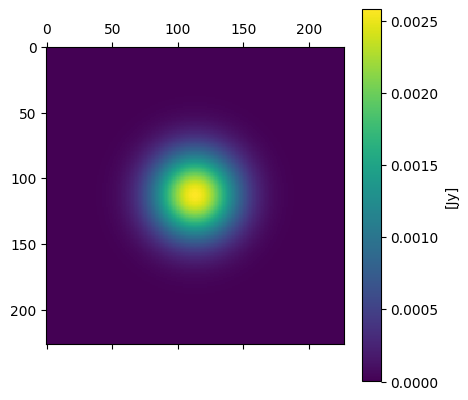

In [11]:
# Generation of the 2D circular Gaussian of Circinus
# TODO: Find a way to extract from the database directly

F_circinus = 8.327 * u.Jy
Angular_size_circinus = 262.25096794270144 *u.mas
FWHM_circinus = 5.34 * u.pc
pixel_size_circinus = 0.1*u.pc
D_circinus = 4.2 *u.Mpc

G_circ_circinus = Circular_Gaussian_profile(FWHM_circinus, F_circinus, pixel_size_circinus, D_circinus, example_FITS, "N", "Circinus", creating_FITS=True)

plt.matshow(G_circ_circinus)
plt.colorbar(label='[Jy]')
plt.show()

Unresolved point source

In [ ]:
pixel_size_circinus = 0.1*u.pc
D_circinus = 4.2 *u.Mpc
pxl_unres_x = 3 
CDELT = 3.90625 *u.mas
FWHM_unres = mas_to_pc(pxl_unres_x*CDELT, D_circinus)
flux_pt = 2.38*u.Jy

pt_source = Circular_Gaussian_profile(FWHM=FWHM_unres, flux=flux_pt, 
                                      pixel_size=pixel_size_circinus, D_source=D_circinus,
                                      example_file=example_FITS, band_name='N', source_name='unres_pt_source_'+str(flux_pt.value)+'Jy', 
                                      creating_FITS=True)

plt.matshow(pt_source)
plt.ylim(0, np.shape(pt_source)[1])
plt.colorbar(label='[Jy]')
plt.show()

### 3.2. Elliptical Gaussian

To implement later to better approximate elliptical objects.

In [12]:
def Elliptical_Gaussian_profile(FWHM_x, FWHM_y, theta, flux, pixel_size, D_source, grid_length_factor, example_file, band_name, source_name, creating_FITS):
    """Generate a 2D Elliptical Gaussian profile.

    Args:
        FWHM_x (Quantity): FWHM of the source in x axis
        FWHM_y (Quantity): FWHM of the source in y axis
        flux (Quantity): Total flux of the source received by the detector
        pixel_size (Quantity): Size of the pixel in pc

    Returns:
        Array(float): 2D array containing the 2D elliptical Gaussian profile
    """
    FWHM_x = FWHM_x.to(u.pc)
    FWHM_x = FWHM_x.value
    FWHM_y = FWHM_y.to(u.pc)
    FWHM_y = FWHM_y.value
    theta = theta.to(u.radian)
    theta = theta.value 
    
    pixel_size = pixel_size.to(u.pc)
    #pixel_size = pixel_size.value
    flux = flux.to(u.Jy)
    flux = flux.value
    
    sigma_x = FWHM_x/(2* np.sqrt(2*np.log(2)))/pixel_size.value
    sigma_y = FWHM_y/(2* np.sqrt(2*np.log(2)))/pixel_size.value
    grid_length = int(grid_length_factor*np.max([sigma_x, sigma_y]))
    
    if grid_length % 2 == 0:
        grid_length += 1
    Grid_size = (grid_length, grid_length)

    x = [i for i in range(Grid_size[0])]
    y = [i for i in range(Grid_size[1])]
    
    # The source is centered at the center of the grid
    x_c = int(Grid_size[0]/2) 
    y_c = int(Grid_size[1]/2)
    I = 1
    G = np.zeros((len(x), len(y)))
    a = np.cos(theta)**2/(2*sigma_x**2)+np.sin(theta)**2/(2*sigma_y**2)
    c = np.cos(theta)**2/(2*sigma_y**2)+np.sin(theta)**2/(2*sigma_x**2) 
    b = -np.cos(theta)*np.sin(theta)/(2*sigma_x**2)+np.cos(theta)*np.sin(theta)/(2*sigma_y**2)
    
    for i in range(len(x)):
        for j in range(len(y)):
            G[i,j] = I*np.exp(-(a*(x[i]-x_c)**2 + 2*b*(x[i]-x_c)*(y[j]-y_c) + c*(y[j]-y_c)**2))
    
    # To normalize the gaussian following the value of the total flux of the source
    somme = np.sum(G)
    ratio = flux/somme 
    G *= ratio

    # Creation of a FITS file to store the Gaussian
    if creating_FITS == True:
        example_data, example_header = fits.getdata(example_file, header=True)
        new_header= example_header.copy()

        CDELT_circinus = pc_to_mas(D_source, pixel_size).to(u.degree)
        new_header['BITPIX'] = -64
        new_header['NAXIS1'] = np.shape(G)[0]
        new_header['NAXIS2'] = np.shape(G)[1]
        new_header['CRPIX1'] = int(np.shape(G)[0]/2)
        new_header['CRPIX2'] = int(np.shape(G)[1]/2)
        new_header["CDELT1"] = CDELT_circinus.value
        new_header["CDELT2"] = CDELT_circinus.value
        new_header['object'] = source_name

        file = '../outputs/models/Elliptical_Gaussian_'+source_name+'_'+band_name+'-band.fits'
        hdu = fits.PrimaryHDU(G, header=new_header)
        hdu.writeto(file, overwrite=True)
    
    return G


#### 3.2.1. L-band
Following the article

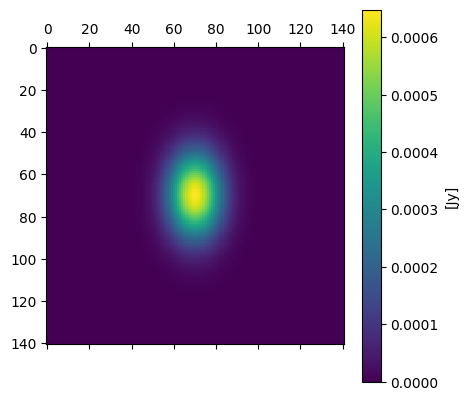

In [11]:
# Generation of the 2D circular Gaussian of Circinus


pixel_size_circinus = 0.01*u.pc
D_circinus = 4.2 *u.Mpc

THETA = 16.3*u.mas 
r = 0.63

FWHM_L_x = mas_to_pc(THETA, D_circinus)

G_ellipt_circinus = Elliptical_Gaussian_profile(FWHM_x=FWHM_L_x, FWHM_y=r*FWHM_L_x, theta=0*u.degree, flux=510*u.mJy, 
                                              pixel_size=pixel_size_circinus, D_source=D_circinus, grid_length_factor=10, 
                                              example_file=example_FITS, band_name="L", source_name="Circinus", creating_FITS=True)

plt.matshow(G_ellipt_circinus)
plt.colorbar(label='[Jy]')
plt.show()

### 3.3. Pt source with extended emission (2 parts)

We can merge a Circular Gaussian with an Elliptical Gaussian to create a pt source with extended emission

In [13]:
def pt_and_extended_source(FWHM, FWHM_x, FWHM_y, theta, flux_circ, flux_ellipt, pixel_size, D_source,  grid_length_factor, d_offset, example_file, band_name, source_name, creating_FITS):
    
    G_circ = Circular_Gaussian_profile(FWHM, flux_circ, pixel_size, D_source, example_file, band_name, source_name, False)
    G_ellipt = Elliptical_Gaussian_profile(FWHM_x, FWHM_y, theta, flux_ellipt, pixel_size, D_source,  grid_length_factor, example_file, band_name, source_name, False)
    G = G_ellipt
    
    half_length_circ = int(np.shape(G_circ)[0]/2)
    d_center_circ = int(np.shape(G_ellipt)[0]/2+ d_offset) 
    
    for i in range(np.shape(G_circ)[0]):
        for j in range(np.shape(G_circ)[1]):
            G[d_center_circ-half_length_circ + i, d_center_circ-half_length_circ + j] += G_circ[i,j]
            
    # Creation of a FITS file to store the Gaussian
    if creating_FITS == True:
        example_data, example_header = fits.getdata(example_file, header=True)
        new_header= example_header.copy()

        CDELT_circinus = pc_to_mas(D_source, pixel_size).to(u.degree)
        new_header['BITPIX'] = -64
        new_header['NAXIS1'] = np.shape(G)[0]
        new_header['NAXIS2'] = np.shape(G)[1]
        new_header['CRPIX1'] = int(np.shape(G)[0]/2)
        new_header['CRPIX2'] = int(np.shape(G)[1]/2)
        new_header["CDELT1"] = CDELT_circinus.value
        new_header["CDELT2"] = CDELT_circinus.value
        new_header['object'] = source_name

        file = '../outputs/models/Pt_and_Extended_Gaussian_'+source_name+'_'+band_name+'-band.fits'
        hdu = fits.PrimaryHDU(G, header=new_header)
        hdu.writeto(file, overwrite=True)
    
    return G

Test with good data.

In [14]:
# Generation of the 2D circular Gaussian of Circinus
pixel_size_circinus = 0.1*u.pc
D_circinus = 4.2 *u.Mpc

pxl_polar_x = 52
pxl_polar_y = 26
pxl_disk_x = pxl_polar_y
pxl_disk_y = 5
pxl_unres_x = 3 # mettre 3
theta_polar = 27*u.degree
CDELT = 3.90625 *u.mas

FWHM_unres = mas_to_pc(pxl_unres_x*CDELT, D_circinus)
FWHM_disk_x = mas_to_pc(pxl_disk_x*CDELT, D_circinus)
FWHM_disk_y = mas_to_pc(pxl_disk_y*CDELT, D_circinus)
FWHM_polar_x = mas_to_pc(pxl_polar_x*CDELT, D_circinus)
FWHM_polar_y = mas_to_pc(pxl_polar_y*CDELT, D_circinus)

FWHM_unres , FWHM_disk_x, FWHM_disk_y , FWHM_polar_x , FWHM_polar_y 


(<Quantity 0.23861923 pc>,
 <Quantity 2.06803336 pc>,
 <Quantity 0.39769872 pc>,
 <Quantity 4.13606672 pc>,
 <Quantity 2.06803336 pc>)

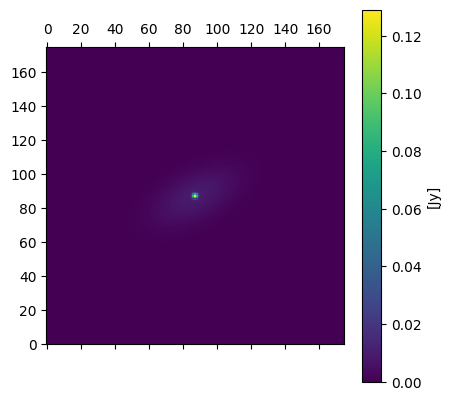

In [16]:

G_pt_and_extended = pt_and_extended_source(FWHM=FWHM_unres, FWHM_y=FWHM_polar_x, FWHM_x=FWHM_polar_y, 
                                           theta=27*u.degree, 
                                           flux_circ=0.77*u.Jy, flux_ellipt=(7.79+1.61)*u.Jy,
                                           pixel_size=pixel_size_circinus, D_source=D_circinus, 
                                           grid_length_factor=10, d_offset=0,
                                           example_file=example_FITS, band_name='N', source_name="Circinus", 
                                           creating_FITS=False)


plt.matshow(G_pt_and_extended)
plt.ylim(0, np.shape(G_pt_and_extended)[1])
plt.colorbar(label='[Jy]')
plt.show()

In [19]:
print(np.sum(G_pt_and_extended))

10.169999999999998


In [14]:
G_ellipt_circinus_unres = Elliptical_Gaussian_profile(FWHM_x=FWHM_polar_y, FWHM_y=FWHM_polar_x, theta=27*u.degree, flux=(7.79+1.61)*u.Jy, 
                                              pixel_size=pixel_size_circinus, D_source=D_circinus, grid_length_factor=10, 
                                              example_file=example_FITS, band_name="N", source_name="Circinus_extended", creating_FITS=True)

### 3.4. Pt source with extended emission (3 parts)

We can merge a Circular Gaussian with two Elliptical Gaussians to create an unres pt source with extended emissions

In [28]:
def pt_and_extended_sources_3(FWHM_polar_x, FWHM_polar_y, FWHM_disk_x, FWHM_disk_y, FWHM_unres, flux_polar, flux_disk, flux_unres, theta_polar, theta_disk, pixel_size, D_source,  grid_length_factor, d_offset, example_file, band_name, source_name, creating_FITS):
    
    G_unres = Circular_Gaussian_profile(FWHM_unres, 
                                        flux_unres, 
                                        pixel_size, D_source, example_file, band_name, source_name, False)
    
    G_polar = Elliptical_Gaussian_profile(FWHM_polar_x, FWHM_polar_y, 
                                          theta_polar, flux_polar, 
                                          pixel_size, D_source,  grid_length_factor, example_file, band_name, source_name, False)
    
    G_disk = Elliptical_Gaussian_profile(FWHM_disk_x, FWHM_disk_y, 
                                         theta_disk, flux_disk, 
                                         pixel_size, D_source, grid_length_factor, example_file, band_name, source_name, False)
    d_center_polar = int(np.shape(G_polar)[0]/2+ d_offset) 
        
    # Adding G_disk
    half_length_disk = int(np.shape(G_disk)[0]/2)

    for i in range(np.shape(G_disk)[0]):
        for j in range(np.shape(G_disk)[1]):
            G_polar[d_center_polar-half_length_disk + i, d_center_polar-half_length_disk + j] += G_disk[i,j]
            
    # Adding G_unres
    half_length_unres = int(np.shape(G_unres)[0]/2)
    
    for i in range(np.shape(G_unres)[0]):
        for j in range(np.shape(G_unres)[1]):
            G_polar[d_center_polar-half_length_unres + i, d_center_polar-half_length_unres + j] += G_unres[i,j]
            
    
    
    # Creation of a FITS file to store the Gaussian
    if creating_FITS == True:
        example_data, example_header = fits.getdata(example_file, header=True)
        new_header= example_header.copy()

        CDELT_circinus = pc_to_mas(D_source, pixel_size).to(u.degree)
        new_header['BITPIX'] = -64
        new_header['NAXIS1'] = np.shape(G_polar)[0]
        new_header['NAXIS2'] = np.shape(G_polar)[1]
        new_header['CRPIX1'] = int(np.shape(G_polar)[0]/2)
        new_header['CRPIX2'] = int(np.shape(G_polar)[1]/2)
        new_header["CDELT1"] = CDELT_circinus.value
        new_header["CDELT2"] = CDELT_circinus.value
        new_header['object'] = source_name

        file = '../outputs/models/3_Pt_and_Extended_Gaussian'+source_name+'_'+band_name+'-band.fits'
        hdu = fits.PrimaryHDU(G_polar, header=new_header)
        hdu.writeto(file, overwrite=True)
    
    return G_polar

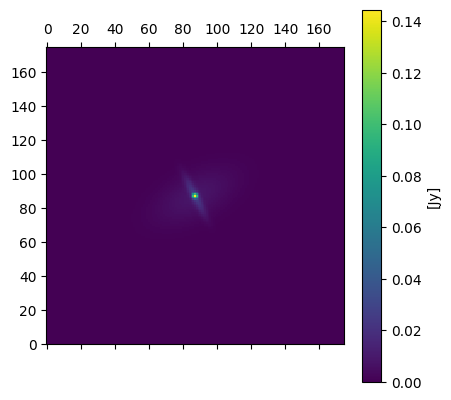

In [32]:
# Generation of the 2D circular Gaussian of Circinus
pixel_size_circinus = 0.1*u.pc
D_circinus = 4.2 *u.Mpc

CDELT = 3.90625 *u.mas


pxl_polar_x = 52
pxl_polar_y = 26
pxl_disk_x = pxl_polar_y
pxl_disk_y = 5
pxl_unres_x = 3 # mettre 3


theta_polar = 27*u.degree
theta_disk = theta_polar + 90*u.degree


FWHM_unres = mas_to_pc(pxl_unres_x*CDELT, D_circinus)
FWHM_disk_x = mas_to_pc(pxl_disk_x*CDELT, D_circinus)
FWHM_disk_y = mas_to_pc(pxl_disk_y*CDELT, D_circinus)
FWHM_polar_x = mas_to_pc(pxl_polar_x*CDELT, D_circinus)
FWHM_polar_y = mas_to_pc(pxl_polar_y*CDELT, D_circinus)

FWHM_unres , FWHM_disk_x, FWHM_disk_y , FWHM_polar_x , FWHM_polar_y 

flux_unres = 0.77*u.Jy
flux_disk = 1.61 *u.Jy
flux_polar = 7.79*u.Jy



G_pt_and_extended_3 = pt_and_extended_sources_3(FWHM_unres=FWHM_unres, flux_unres=flux_unres,
                                              FWHM_polar_x=FWHM_polar_y, FWHM_polar_y=FWHM_polar_x, flux_polar=flux_polar, theta_polar=theta_polar,
                                              FWHM_disk_x=FWHM_disk_y, FWHM_disk_y=FWHM_disk_x, flux_disk=flux_disk, theta_disk=theta_disk,
                                              pixel_size=pixel_size_circinus, D_source=D_circinus, 
                                              grid_length_factor=10, d_offset=0,
                                              example_file=example_FITS, band_name='N', source_name="Circinus", 
                                              creating_FITS=True)


plt.matshow(G_pt_and_extended_3)
plt.ylim(0, np.shape(G_pt_and_extended_3)[1])
plt.colorbar(label='[Jy]')
plt.show()

### 3.5. Pt source (for PSF)
We also need an unresolved Pt source to do the PSF substraction

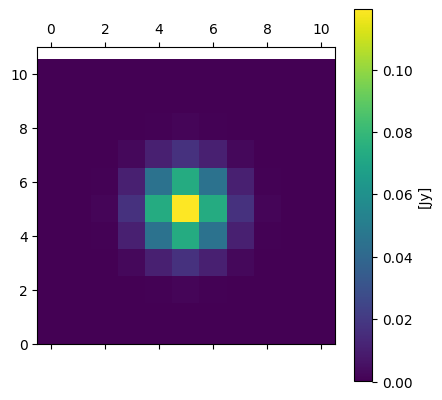

In [33]:
pixel_size_circinus = 0.1*u.pc
D_circinus = 4.2 *u.Mpc
pxl_unres_x = 3 
CDELT = 3.90625 *u.mas
FWHM_unres = mas_to_pc(pxl_unres_x*CDELT, D_circinus)
flux_pt = 0.77*u.Jy

pt_source_077 = Circular_Gaussian_profile(FWHM=FWHM_unres, flux=flux_pt, 
                                      pixel_size=pixel_size_circinus, D_source=D_circinus,
                                      example_file=example_FITS, band_name='N', source_name='unres_pt_source_'+str(flux_pt.value)+'Jy', 
                                      creating_FITS=True)

plt.matshow(pt_source_077)
plt.ylim(0, np.shape(pt_source_077)[1])
plt.colorbar(label='[Jy]')
plt.show()

### 3.5. Real Circinus FITS file
We need to rescale it because the total flux of the image is normalised.

In [8]:
real_data, real_header = fits.getdata(file_real_circinus_N_band_untouched, header=True)
Total_Flux_circ = (7.79+1.61+0.77)*u.Jy
real_data = real_data * Total_Flux_circ/np.sum(real_data)
new_header = real_header.copy()
CDELT = (real_header['CDELT1']*2*u.mas).to(u.degree)

new_header['BUNIT'] = "Jy"
new_header['CDELT1'] = CDELT.value
new_header['CDELT2'] = CDELT.value
new_header['CUNIT1'] = "deg"
new_header['CUNIT2'] = "deg"
new_header['CRPIX1'] = int(real_header['NAXIS1']/2)
new_header['CRPIX2'] = int(real_header['NAXIS2']/2)
fits.writeto(file_real_circinus_N_band, real_data, new_header, overwrite=True)


In [9]:
print(np.sum(real_data))

10.169999321444433 Jy


## Sources

[*"The subarcsecond mid-infrared view of local active galactic nuclei: I. The N- and Q-band imaging atlas"* by D. Asmus et al.](https://arxiv.org/abs/1310.2770)